# Equivariant Neural Networks with PyTorch + e2cnn (Lecture Companion)

This notebook is a hands-on companion to the **"Equivariant Neural Networks"** lecture (Anna Scaife, NASA AI/ML STIG Lecture Series, 2 March 2026).

It demonstrates:

- **Invariance vs equivariance** (translations, rotations, reflections)
- That **standard CNNs are translation-equivariant** (weight sharing), and how **pooling** yields invariance
- How to build **group-equivariant / G-steerable CNNs** using **[`e2cnn`](https://github.com/QUVA-Lab/e2cnn)** in PyTorch
- A small experiment comparing **vanilla CNN** vs **rotation-equivariant CNN** on a toy "radio-jet-like" morphology task

> Notes:
> - Designed to run on **Python 3.11**.
> - Runs on CPU, but will be faster on a GPU.
> - The toy dataset is synthetic so the notebook is fully self-contained.

Reference repos:
- https://github.com/QUVA-Lab/e2cnn  
- https://github.com/as595/E2CNNRadGal

---

## Housekeeping 

### Environment setup (Python 3.11)

Recommended, compatible versions for this notebook:

- Python **3.10**
- `torch` **>= 2.1, < 2.4** (CPU or CUDA wheel)
- `torchvision` **>= 0.16, < 0.19** (match torch)
- `e2cnn==0.2.3`
- `numpy>=1.24`, `scipy>=1.10`, `matplotlib>=3.7`, `tqdm>=4.66`

If `torch` is already installed, you may only need to install `e2cnn`.

In [1]:
# If needed, uncomment and run.
# IMPORTANT: Install torch/torchvision according to https://pytorch.org/get-started/locally/
# (CPU vs CUDA wheels differ).
#
# !pip install -U pip
# !pip install "torch>=2.1,<2.4" "torchvision>=0.16,<0.19" --index-url https://download.pytorch.org/whl/cpu
# !pip install "e2cnn==0.2.3" "numpy>=1.24" "scipy>=1.10" "matplotlib>=3.7" "tqdm>=4.66"

In [2]:
import math
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from e2cnn import gspaces
from e2cnn import nn as e2nn

print("Python:", sys.version.split()[0])
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("e2cnn:", e2nn.__package__)
device = "cuda" if torch.cuda.is_available() else "cpu"

Python: 3.11.5
Torch: 2.10.0
CUDA available: False
e2cnn: e2cnn.nn


### Dataset retrieval (MiraBest)

We're going to use two datasets in this notebook. 

(i) The first is a toy dataset of "jets" that we will create dynamically. 

(ii) The other is the MiraBest ML dataset of of Fanaroff-Riley (FR) radio galaxies drawn from [Miraghaei and Best 2017](https://academic.oup.com/mnras/article/466/4/4346/2843096). The full dataset consists of FRI, FRII and hybrid FR sources, labelled as either confidently or uncertainly classified, and with any nonstandard morphology noted. MiraBest images come from the [VLA FIRST sky survey](https://sundog.stsci.edu/). All images have dimensions of 150 x 150 pixels, with one pixel equivalent to an angular size of 1.8". The dataset is split into 7 training batches and a test batch, each composed of 157 images. The number of objects of each class in each batch is roughly consistent between batches, and the test batch contains at least one example of every class. 

MiraBest is available on Zenodo [here](https://zenodo.org/records/4288837). So let's go and get it.

In [3]:
from pathlib import Path
import urllib.request
import tarfile
import importlib.util

mirabest_root = Path("./data/mirabest")
mirabest_root.mkdir(parents=True, exist_ok=True)

# Files from the Zenodo record requested by the user
mirabest_py_url = "https://zenodo.org/records/4288837/files/MiraBest.py?download=1"
mirabest_tgz_url = "https://zenodo.org/records/4288837/files/batches.tar.gz?download=1"

mirabest_py_path = mirabest_root / "MiraBest.py"
mirabest_tgz_path = mirabest_root / "batches.tar.gz"
batches_dir = mirabest_root / "batches"

def maybe_download(url, dest):
    if dest.exists():
        print(f"Already present: {dest}")
        return
    print(f"Downloading {url} -> {dest}")
    urllib.request.urlretrieve(url, dest)

# Download the dataset class and archive
maybe_download(mirabest_py_url, mirabest_py_path)
maybe_download(mirabest_tgz_url, mirabest_tgz_path)

# Extract the archive if needed
if not batches_dir.exists():
    print("Extracting dataset archive...")
    with tarfile.open(mirabest_tgz_path, "r:gz") as tar:
        tar.extractall(path=mirabest_root)
else:
    print(f"Already extracted: {batches_dir}")

# Dynamically import the dataset class
spec = importlib.util.spec_from_file_location("mirabest_module", mirabest_py_path)
mirabest_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mirabest_module)
MiraBest = mirabest_module.MiraBest

print("Loaded MiraBest class from:", mirabest_py_path)

Already present: data/mirabest/MiraBest.py
Already present: data/mirabest/batches.tar.gz
Already extracted: data/mirabest/batches
Loaded MiraBest class from: data/mirabest/MiraBest.py


---

## Invariance vs equivariance (building intuition)

- **Invariant**: output doesn't change under a transform (useful for classification)
- **Equivariant**: output changes predictably with the transform (useful for feature maps)

Let's start by looking at translations:

Files already downloaded and verified


/Users/ascaife/TALKS/NASA/tutorial/data/mirabest/MiraBest.py:91: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding='latin1')


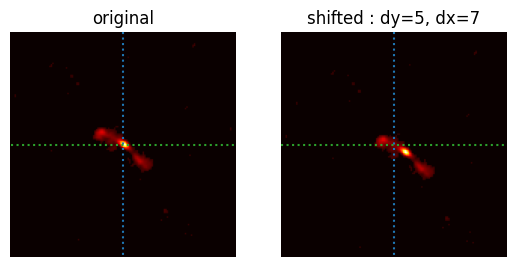

In [4]:
# note that for properly using the MiraBest dataset we should use normalisations from Porter & Scaife arXiv:2305.11108
mirabest_transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize([0.5],[0.5])]) 

# choose an example data sample:
i = 3 # random index from dataset
mb_train = MiraBest(root="./data/mirabest", train=True, download=True, transform=mirabest_transform)
example = torch.tensor(mb_train.data[i]).float() # dim = (150,150,1)

# specify a translation in 2-dimensions
dy, dx = 5, 7
example_shifted = torch.roll(example, shifts=(dy, dx), dims=(0, 1))

plt.subplot(121)
plt.imshow(example, cmap='hot')
plt.title('original')
plt.axis('off')
plt.plot([75,75], [0,149], ':', 'w'); plt.plot([0,149], [75,75], ':', 'w')
plt.subplot(122)
plt.imshow(example_shifted, cmap='hot')
plt.title(f"shifted : dy={dy}, dx={dx}")
plt.axis('off')
plt.plot([75,75], [0,149], ':', 'w'); plt.plot([0,149], [75,75], ':', 'w')
plt.show()

At each pixel $x \in \mathbb{R}^d$ there is a set of features, $F(x) \in \mathbb{R}^c$.

Say we have a function:

$$\mathcal{L}(F) : \mathbb{R}^d \rightarrow \mathbb{R}^{c_{\rm out}}$$

i.e. at each pixel it takes a set of input features with dimension $c_{in}$ and produces a set of output features with dimension $c_{out}$.

The function is invariant to translations $t \in (\mathbb{R}^d, + )$ if

$$\mathcal{L} (t \triangleright F) =  \mathcal{L}(F).$$

In [5]:
# define a little random MLP:
torch.manual_seed(0)
mlp = nn.Sequential(
    nn.Flatten(),
    nn.Linear(150*150, 128),
#    nn.ReLU(),
#    nn.Linear(128, 32),
)

# this is just a hack to put an axis in for batch index so torch is happy
x = example.squeeze().unsqueeze(0)
x_shift = example_shifted.squeeze().unsqueeze(0)

# encode both the shifted and unshifted images through the MLP:
with torch.no_grad():
    z = mlp(x)
    z_shift = mlp(x_shift)

# evaluate the difference:
mlp_rel_change = (z_shift - z).abs().mean() / (z.abs().mean() + 1e-8)
cos_sim = F.cosine_similarity(z, z_shift).mean()
print(f"-----> MLP relative output change: {mlp_rel_change.item():.3e}")
print(f"-----> MLP cosine similarity (z vs z_shift): {cos_sim.item():.3f}")

MLP relative output change: 9.974e-01
MLP cosine similarity (z vs z_shift): 0.459


We can see that 

$$\mathcal{L} (t \triangleright F) - \mathcal{L}(F) \neq 0$$

so the MLP is not invariant to the translation. 

---

## Convolutions are equivariant to translation

At each pixel $x \in \mathbb{R}^d$ there is a set of features, $F(x) \in \mathbb{R}^c$.
Say we have a function:

$$\mathcal{L}(F) : \mathbb{R}^d \rightarrow \mathbb{R}^{c_{\rm out}}$$
 
i.e. at each pixel it takes a set of input features with dimension $c_{in}$ and produces a set of output features with dimension $c_{out}$.
The function is equivariant to translations $t \in (\mathbb{R}^d, + )$ if

$$\mathcal{L} (t \triangleright F) =  t \triangleright \mathcal{L}(F)$$

i.e. it commutes with the actions of the group.

Set up a little test to check on the translational equivariance of a convolutional layer:

In [6]:
c_in =1; c_out = 1 # input channels and output channels (you can change the output channels from 1 if you like)

torch.manual_seed(0)
conv = nn.Conv2d(c_in, c_out, kernel_size=5, padding=2, bias=False).to(device) # define a convolutional layer

with torch.no_grad():
    y = conv(x) # encode the original image through the convolutional layer
    y_shift = conv(x_shift) # encode the translated image through the convolutional layer
    y_expected = torch.roll(y, shifts=(dy, dx), dims=(1, 2)) # translate the encoding of the original image
    equiv_err = (y_shift - y_expected).abs().mean() / (y_expected.abs().mean() + 1e-8) 

print(f"-----> CNN equivariance relative error: {equiv_err.item():.3e}")

CNN equivariance relative error: 0.000e+00


We can see that 

$$\mathcal{L} (t \triangleright F) -  t \triangleright \mathcal{L}(F) = 0$$

as expected for equivariance.

Let's visualise the translated images and the feature space of the convolutions just for completeness.

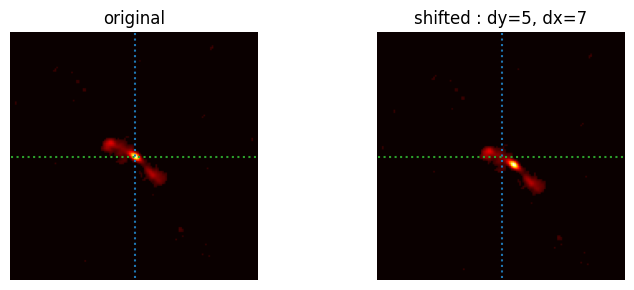

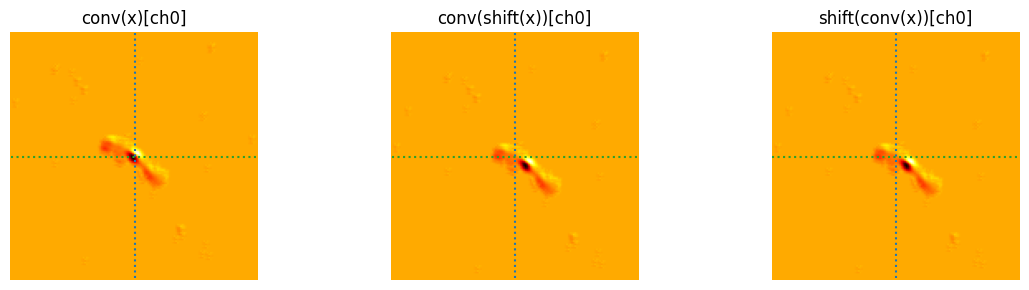

In [7]:
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1); plt.imshow(x[0], cmap="hot"); plt.axis("off"); plt.title('original')
plt.plot([75,75], [0,149], ':', 'w'); plt.plot([0,149], [75,75], ':', 'w')
plt.subplot(1, 2, 2); plt.imshow(x_shift[0], cmap="hot"); plt.axis("off"); plt.title(f"shifted : dy={dy}, dx={dx}")
plt.plot([75,75], [0,149], ':', 'w'); plt.plot([0,149], [75,75], ':', 'w')
plt.tight_layout(); plt.show()


plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1); plt.imshow(y[0], cmap="hot"); plt.title("conv(x)[ch0]"); plt.axis("off")
plt.plot([75,75], [0,149], ':', 'w'); plt.plot([0,149], [75,75], ':', 'w')
plt.subplot(1, 3, 2); plt.imshow(y_shift[0], cmap="hot"); plt.title("conv(shift(x))[ch0]"); plt.axis("off")
plt.plot([75,75], [0,149], ':', 'w'); plt.plot([0,149], [75,75], ':', 'w')
plt.subplot(1, 3, 3); plt.imshow(y_expected[0], cmap="hot"); plt.title("shift(conv(x))[ch0]"); plt.axis("off")
plt.plot([75,75], [0,149], ':', 'w'); plt.plot([0,149], [75,75], ':', 'w')
plt.tight_layout(); plt.show()

---

## Convolutions are *not* equivariant to rotation

At each pixel $x \in \mathbb{R}^d$ there is a set of features, $F(x) \in \mathbb{R}^c$.
Say we have a function:

$$\mathcal{L}(F) : \mathbb{R}^d \rightarrow \mathbb{R}^{c_{\rm out}}$$
 
i.e. at each pixel it takes a set of input features with dimension $c_{in}$ and produces a set of output features with dimension $c_{out}$.
The function is equivariant to rotations $g \in SO(2)$ if

$$\mathcal{L} (g \triangleright F) =  g \triangleright \mathcal{L}(F)$$

i.e. it commutes with the actions of the group.

Set up a little test to check on the rotational equivariance of a convolutional layer:

In [8]:
theta = 90
rotater = transforms.RandomRotation(degrees=(theta, theta))
x_rotate = rotater(example.squeeze().unsqueeze(0))

c_in =1; c_out = 1 # input channels and output channels

torch.manual_seed(0)
conv = nn.Conv2d(c_in, c_out, kernel_size=5, padding=2, bias=False).to(device) # define a convolutional layer

with torch.no_grad():
    y = conv(x) # encode the original image through the convolutional layer
    y_rotate = conv(x_rotate) # encode the translated image through the convolutional layer
    y_expected = rotater(y) # translate the encoding of the original image
    equiv_err = (y_rotate - y_expected).abs().mean() / (y_expected.abs().mean() + 1e-8) 

print(f"-----> CNN equivariance relative error: {equiv_err.item():.3e}")

CNN equivariance relative error: 1.217e+00


We can see that 

$$\mathcal{L} (g \triangleright F) -  g \triangleright \mathcal{L}(F) \neq 0$$

as expected for **non-equivariance**.

Let's visualise the rotated images and the feature space of the convolutions just for completeness.

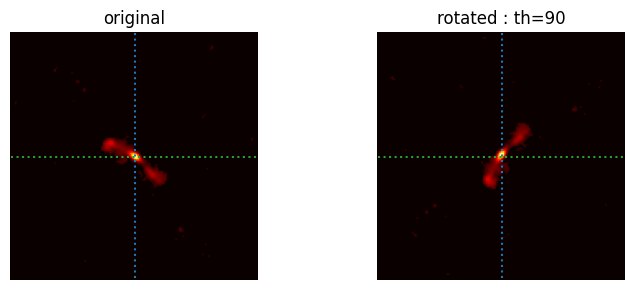

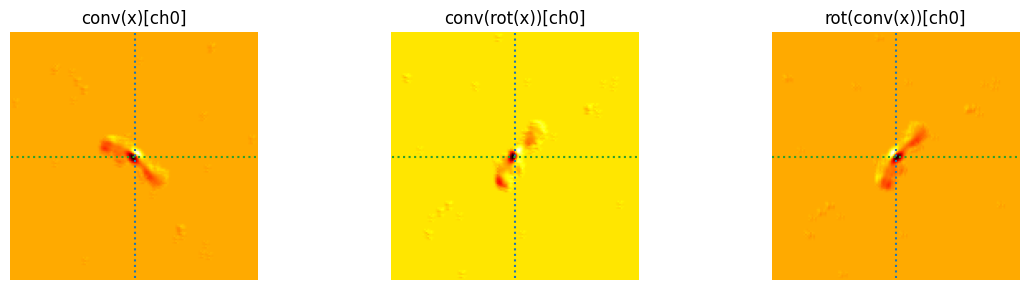

In [9]:
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1); plt.imshow(x[0], cmap="hot"); plt.axis("off"); plt.title('original')
plt.plot([75,75], [0,149], ':', 'w'); plt.plot([0,149], [75,75], ':', 'w')
plt.subplot(1, 2, 2); plt.imshow(x_rotate[0], cmap="hot"); plt.axis("off"); plt.title(f"rotated : th={theta}")
plt.plot([75,75], [0,149], ':', 'w'); plt.plot([0,149], [75,75], ':', 'w')
plt.tight_layout(); plt.show()


plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1); plt.imshow(y[0], cmap="hot"); plt.title("conv(x)[ch0]"); plt.axis("off")
plt.plot([75,75], [0,149], ':', 'w'); plt.plot([0,149], [75,75], ':', 'w')
plt.subplot(1, 3, 2); plt.imshow(y_rotate[0], cmap="hot"); plt.title("conv(rot(x))[ch0]"); plt.axis("off")
plt.plot([75,75], [0,149], ':', 'w'); plt.plot([0,149], [75,75], ':', 'w')
plt.subplot(1, 3, 3); plt.imshow(y_expected[0], cmap="hot"); plt.title("rot(conv(x))[ch0]"); plt.axis("off")
plt.plot([75,75], [0,149], ':', 'w'); plt.plot([0,149], [75,75], ':', 'w')
plt.tight_layout(); plt.show()

---

## Demonstrating a lack of invariance/equivariance in model training

Here we are going to look at the effect of convolutions being non-equivariant to rotation by contrasting model performance for a standard CNN in the cases where:

* training data have full rotational augmentation; test data have full rotational augmentation;
* training data have partial rotational augmentation; test data have full rotational augmentation

and for a group-equivariant CNN where:

* training data have partial rotational augmentation; test data have full rotational augmentation.

To do this we're going to use a toy dataset of straight vs bent "jets":

- **Class 0:** straight line segment
- **Class 1:** bent / kinked morphology

Then we rotate each sample by a random angle.

The models in this section are **not optimised**, they are just being used to illustrate general behaviours. 

### Toy dataset creation

First let's create some data:

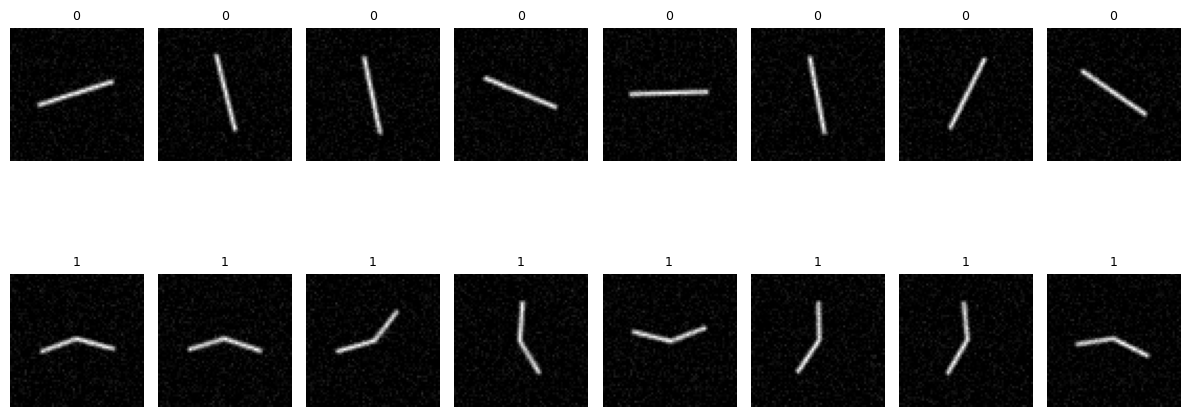

In [10]:
def draw_line(img, p0, p1, width=1.6, val=1.0):
    # Thick line by distance-to-segment thresholding
    h, w = img.shape
    yy, xx = np.mgrid[0:h, 0:w].astype(np.float32)
    x0, y0 = p0
    x1, y1 = p1

    vx, vy = (x1 - x0), (y1 - y0)
    vv = vx * vx + vy * vy + 1e-8

    t = ((xx - x0) * vx + (yy - y0) * vy) / vv
    t = np.clip(t, 0.0, 1.0)
    projx = x0 + t * vx
    projy = y0 + t * vy

    dist = np.sqrt((xx - projx) ** 2 + (yy - projy) ** 2)
    mask = dist <= width
    soft = np.clip(1.0 - (dist / (width + 1e-6)), 0.0, 1.0)
    img[:] = np.maximum(img, val * soft * mask.astype(np.float32))
    return img

def rotate_image(img, angle_rad):
    # Rotate around center using torch grid_sample (no extra deps)
    x = torch.tensor(img, dtype=torch.float32)[None, None]  # 1x1xHxW
    h, w = img.shape
    theta = torch.tensor([
        [ math.cos(angle_rad), -math.sin(angle_rad), 0.0 ],
        [ math.sin(angle_rad),  math.cos(angle_rad), 0.0 ],
    ], dtype=torch.float32)[None]
    grid = F.affine_grid(theta, size=(1, 1, h, w), align_corners=False)
    y = F.grid_sample(x, grid, mode="bilinear", padding_mode="zeros", align_corners=False)
    return y[0, 0].numpy()

def make_canonical(kind, size=64):
    img = np.zeros((size, size), dtype=np.float32)
    cx, cy = (size / 2, size / 2)
    if kind == 0:
        draw_line(img, (cx - 18, cy), (cx + 18, cy), width=1.8, val=1.0)
    else:
        draw_line(img, (cx - 18, cy), (cx, cy), width=1.8, val=1.0)
        draw_line(img, (cx, cy), (cx + 14, cy - 10), width=1.8, val=1.0)
    return img

def make_sample(kind, size=64, angle=None, noise=0.05):
    img = make_canonical(kind, size=size)
    if angle is None:
        angle = np.random.uniform(0, 2*np.pi)
    img = rotate_image(img, angle)
    img = img + np.random.normal(0.0, noise, size=img.shape).astype(np.float32)
    return np.clip(img, 0.0, 1.0)

def show_images(imgs, titles=None, ncols=6, figsize=(12, 4)):
    imgs = imgs.detach().cpu()
    if imgs.ndim == 4:
        imgs = imgs[:, 0]
    n = imgs.shape[0]
    ncols = min(ncols, n)
    nrows = int(math.ceil(n / ncols))
    plt.figure(figsize=(figsize[0], figsize[1] * nrows))
    for i in range(n):
        ax = plt.subplot(nrows, ncols, i + 1)
        ax.imshow(imgs[i], cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
        if titles:
            ax.set_title(str(titles[i]), fontsize=9)
    plt.tight_layout()
    plt.show()
    
np.random.seed(0)
samples, labels = [], []
for k in [0, 1]:
    for _ in range(8):
        samples.append(make_sample(k))
        labels.append(k)

show_images(torch.tensor(np.stack(samples))[:, None], titles=labels, ncols=8, figsize=(12, 3))

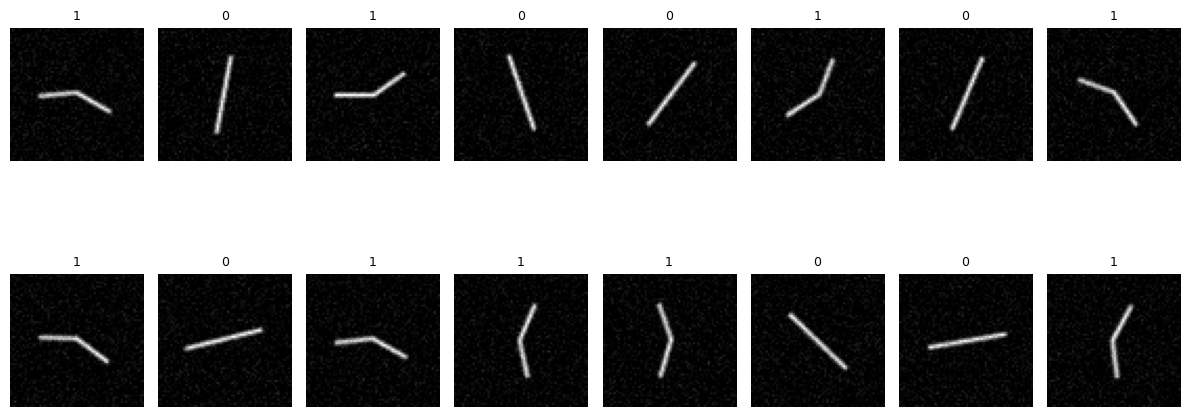

In [11]:
class ToyJets(torch.utils.data.Dataset):
    def __init__(self, n, size=64, train=True, rot_range=(0.0, 2*np.pi), seed=0):
        self.n = n
        self.size = size
        self.train = train
        self.rot_range = rot_range
        self.rng = np.random.RandomState(seed)

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        y = idx % 2
        angle = self.rng.uniform(self.rot_range[0], self.rot_range[1])
        img = make_sample(int(y), size=self.size, angle=angle, noise=0.05 if self.train else 0.03)
        x = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        return x, torch.tensor(y, dtype=torch.long)

def make_loaders(rot_train=(0.0, 2*np.pi), rot_test=(0.0, 2*np.pi), batch_size=64, size=64):
    train_ds = ToyJets(n=4000, size=size, train=True, rot_range=rot_train, seed=1)
    test_ds  = ToyJets(n=1000, size=size, train=False, rot_range=rot_test, seed=2)
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader  = torch.utils.data.DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, test_loader

train_loader, test_loader = make_loaders()
x, y = next(iter(train_loader))
show_images(x[:16], titles=y[:16].tolist(), ncols=8, figsize=(12, 3))

---

## Baseline: standard CNN

Let's start by introducing fully rotated data into both the training and test datasets for a standard CNN.

In [12]:
class VanillaCNN(nn.Module):
    def __init__(self, in_ch=1, n_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, 6, 5), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(6, 16, 5), nn.ReLU(),
            nn.MaxPool2d(2),
#            nn.Conv2d(32, 64, 5), nn.ReLU(),
#            nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # global pooling -> translation-invariant
            nn.Flatten(),
            nn.Linear(16, 120), nn.ReLU(),
            nn.Linear(120, 84), nn.ReLU(),
            nn.Linear(84, n_classes),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # global pooling -> translation-invariant
            nn.Flatten(),
            nn.Linear(16, n_classes)
        )

    def forward(self, x):
        return self.head(self.features(x))
#        return self.classifier(self.features(x))

In [13]:
@torch.no_grad()
def evaluate(model, loader, device="cpu"):
    model.eval()
    correct = 0
    total = 0
    loss_sum = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss_sum += F.cross_entropy(logits, y, reduction="sum").item()
        correct += (logits.argmax(1) == y).sum().item()
        total += y.numel()
    return {"acc": correct / total, "loss": loss_sum / total}

def train(model, train_loader, test_loader, device="cpu", epochs=6, lr=2e-3):

    tr_acc=[]; te_acc=[]
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    
    for ep in range(1, epochs + 1):
        model.train()

        for x, y in tqdm(train_loader, desc=f"epoch {ep}/{epochs}", leave=False):
            x, y = x.to(device), y.to(device)
            opt.zero_grad(set_to_none=True)
            loss = F.cross_entropy(model(x), y)
            loss.backward()
            opt.step()

        tr = evaluate(model, train_loader, device)
        te = evaluate(model, test_loader, device)
        
        tr_acc.append(tr['acc']); te_acc.append(te['acc'])
        print(f"ep {ep}: train loss= {tr['loss']:.3f} train acc={tr['acc']:.3f}  test acc={te['acc']:.3f}")
    return model, tr_acc, te_acc

If we use full rotations $(0,360)$ degrees at both train and test time, then the test accuracy tracks the train accuracy:

In [14]:
train_loader_full, test_loader_full = make_loaders(rot_train=(0.0, 2*np.pi), rot_test=(0.0, 2*np.pi), batch_size=64, size=64)
vanilla_full, tr_acc, te_acc = train(VanillaCNN(), train_loader_full, test_loader_full, device=device, epochs=10, lr=0.002)

print("Final (vanilla_full) full-rotation test:", evaluate(vanilla_full, test_loader_full, device=device))

epoch 1/10:   0%|          | 0/63 [00:00<?, ?it/s]

ep 1: train loss= 0.693 train acc=0.500  test acc=0.500


epoch 2/10:   0%|          | 0/63 [00:00<?, ?it/s]

ep 2: train loss= 0.694 train acc=0.500  test acc=0.500


epoch 3/10:   0%|          | 0/63 [00:00<?, ?it/s]

...

ep 8: train loss= 0.376 train acc=0.817  test acc=0.731


epoch 9/10:   0%|          | 0/63 [00:00<?, ?it/s]

ep 9: train loss= 0.175 train acc=0.960  test acc=0.976


epoch 10/10:   0%|          | 0/63 [00:00<?, ?it/s]

ep 10: train loss= 0.128 train acc=0.975  test acc=0.969
Final (vanilla_full) full-rotation test: {'acc': 0.968, 'loss': 0.12700397896766663}


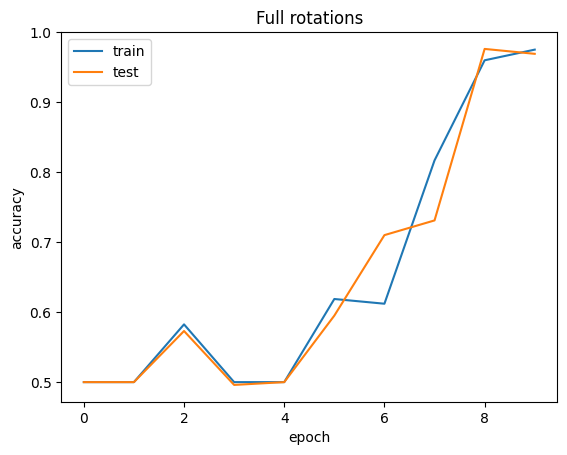

In [15]:
plt.plot(tr_acc, label="train")
plt.plot(te_acc, label="test")
plt.ylabel("accuracy"); plt.xlabel("epoch")
plt.title("Full rotations")
plt.legend()
plt.show()

---

## Rotation stress test

Train only on rotations in **0..90°**, test on **0..360°**.

In this case, the test accuracy stops tracking the train accuracy after a while.

In [16]:
train_loader_limited, test_loader_full = make_loaders(rot_train=(0.0, 0.5*np.pi), rot_test=(0.0, 2*np.pi))
vanilla_limited, tr_acc, te_acc = train(VanillaCNN(), train_loader_limited, test_loader_full, device=device, epochs=10, lr=0.002)

print("Final (vanilla_limited) full-rotation test:", evaluate(vanilla_limited, test_loader_full, device=device))

epoch 1/10:   0%|          | 0/63 [00:00<?, ?it/s]

ep 1: train loss= 0.689 train acc=0.654  test acc=0.522


epoch 2/10:   0%|          | 0/63 [00:00<?, ?it/s]

ep 2: train loss= 0.571 train acc=0.715  test acc=0.565


epoch 3/10:   0%|          | 0/63 [00:00<?, ?it/s]

...

ep 8: train loss= 0.025 train acc=0.998  test acc=0.711


epoch 9/10:   0%|          | 0/63 [00:00<?, ?it/s]

ep 9: train loss= 0.035 train acc=0.995  test acc=0.665


epoch 10/10:   0%|          | 0/63 [00:00<?, ?it/s]

ep 10: train loss= 0.019 train acc=0.998  test acc=0.684
Final (vanilla_limited) full-rotation test: {'acc': 0.696, 'loss': 10.066221496582031}


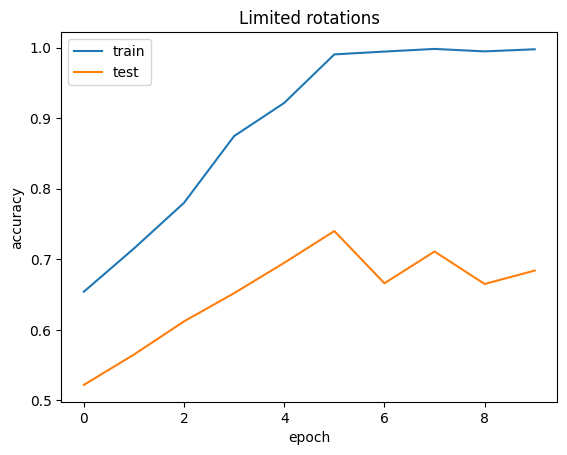

In [17]:
plt.plot(tr_acc, label="train")
plt.plot(te_acc, label="test")
plt.ylabel("accuracy"); plt.xlabel("epoch")
plt.title("Limited rotations")
plt.legend()
plt.show()

---

## Group-equivariant CNN with `e2cnn` (C₈ rotations)

We define a **C₈** rotation-equivariant network and use **GroupPooling** to obtain a **rotation-invariant** representation for classification.

In [28]:
class E2CNN_RotEq(nn.Module):
    def __init__(self, N=8, n_classes=2):
        super().__init__()
        self.r2_act = gspaces.Rot2dOnR2(N=N)  # C_N rotations

        in_type = e2nn.FieldType(self.r2_act, [self.r2_act.trivial_repr])
        t6 = e2nn.FieldType(self.r2_act, 6 * [self.r2_act.regular_repr])
        t16 = e2nn.FieldType(self.r2_act, 16 * [self.r2_act.regular_repr])
        t32 = e2nn.FieldType(self.r2_act, 32 * [self.r2_act.regular_repr])

        self.block1 = e2nn.SequentialModule(
            e2nn.R2Conv(in_type, t6, kernel_size=5, padding=2, bias=False),
            e2nn.InnerBatchNorm(t6),
            e2nn.ReLU(t6, inplace=True),
            e2nn.PointwiseMaxPool(t6, kernel_size=2, stride=1),
        )
        self.block2 = e2nn.SequentialModule(
            e2nn.R2Conv(t6, t16, kernel_size=5, padding=2, bias=False),
            e2nn.InnerBatchNorm(t16),
            e2nn.ReLU(t16, inplace=True),
#            e2nn.PointwiseMaxPool(t16, kernel_size=2, stride=1),
        )
#        self.block3 = e2nn.SequentialModule(
#            e2nn.R2Conv(t16, t32, kernel_size=3, padding=1, bias=False),
#            e2nn.InnerBatchNorm(t32),
#            e2nn.ReLU(t32, inplace=True),
#        )

        self.gpool = e2nn.GroupPooling(t16)  # makes features invariant to rotations
        out_type = self.gpool.out_type
        self.avgpool = e2nn.PointwiseAdaptiveAvgPool(out_type, (1, 1))
        
        self.classifier = nn.Linear(out_type.size, n_classes)

        self.head = nn.Sequential(
            nn.Linear(out_type.size, 120), nn.ReLU(),
            nn.Linear(120, 84), nn.ReLU(),
            nn.Linear(84, n_classes),
        )

        self.in_type = in_type

    def forward(self, x):
        x = e2nn.GeometricTensor(x, self.in_type)
        x = self.block1(x)
        x = self.block2(x)
#        x = self.block3(x)
        x = self.gpool(x)
        x = self.avgpool(x)
        x = x.tensor.flatten(1)
        return self.classifier(x)

In [29]:
e2_model, tr_acc, te_acc = train(E2CNN_RotEq(N=8), train_loader_limited, test_loader_full, device=device, epochs=6, lr=2e-3)

print("Final (e2cnn) full-rotation test:", evaluate(e2_model, test_loader_full, device=device))

epoch 1/6:   0%|          | 0/63 [00:00<?, ?it/s]

ep 1: train loss= 0.679 train acc=0.500  test acc=0.500


epoch 2/6:   0%|          | 0/63 [00:00<?, ?it/s]

ep 2: train loss= 0.662 train acc=0.502  test acc=0.501


epoch 3/6:   0%|          | 0/63 [00:00<?, ?it/s]

...

ep 4: train loss= 0.601 train acc=0.620  test acc=0.808


epoch 5/6:   0%|          | 0/63 [00:00<?, ?it/s]

ep 5: train loss= 0.554 train acc=0.896  test acc=0.679


epoch 6/6:   0%|          | 0/63 [00:00<?, ?it/s]

ep 6: train loss= 0.517 train acc=0.928  test acc=0.712
Final (e2cnn) full-rotation test: {'acc': 0.73, 'loss': 0.5243946590423584}


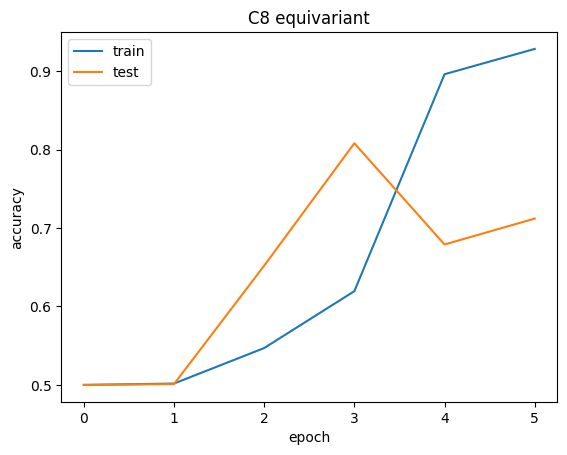

In [30]:
plt.plot(tr_acc, label="train")
plt.plot(te_acc, label="test")
plt.ylabel("accuracy"); plt.xlabel("epoch")
plt.title("C8 equivariant")
plt.legend()
plt.show()

### Compare performance

These two models use the same partially rotated trainign data and are evaluated on a fully rotated test set. 


In [31]:
print("Vanilla:", evaluate(vanilla_limited, test_loader_full, device=device))
print("E2CNN :", evaluate(e2_model, test_loader_full, device=device))

Vanilla: {'acc': 0.671, 'loss': 10.911916809082031}
E2CNN : {'acc': 0.731, 'loss': 0.5284799880981446}


---

## Equivariance check 

Let's take a look at the same equivariance tests that we performed earlier for standard convolutions, but now using the rotationally equivariant convolutions from E2CNN.

In [22]:
theta = 90
rotater = transforms.RandomRotation(degrees=(theta, theta))

x = example.squeeze().unsqueeze(0).unsqueeze(0)
x_rotate = rotater(x)

r2_act = gspaces.Rot2dOnR2(N=4)  # C_N rotations
in_type = e2nn.FieldType(r2_act, [r2_act.trivial_repr])

t1 = e2nn.FieldType(r2_act, 1 * [r2_act.regular_repr])
conv = e2nn.R2Conv(in_type, t1, kernel_size=5, padding=2, bias=False)
pool = e2nn.GroupPooling(t1)

with torch.no_grad():
    e2_model.eval()
    gx = e2nn.GeometricTensor(x.to(device), in_type)
    y = pool(conv(gx)).tensor # encode the original image through the convolutional layer
    
    gx_rot = e2nn.GeometricTensor(x_rotate.to(device), in_type)
    y_rotate = pool(conv(gx_rot)).tensor
    
    y_expected = rotater(y) # rotate the encoding of the original image
    
    equiv_err = (y_rotate - y_expected).abs().mean() / (y_expected.abs().mean() + 1e-8) 

print(f"CNN equivariance relative error: {equiv_err.item():.3e}")

CNN equivariance relative error: 1.003e-07


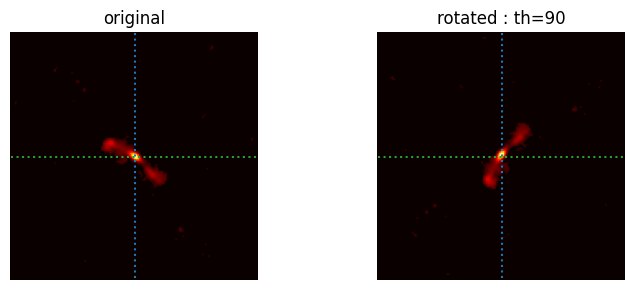

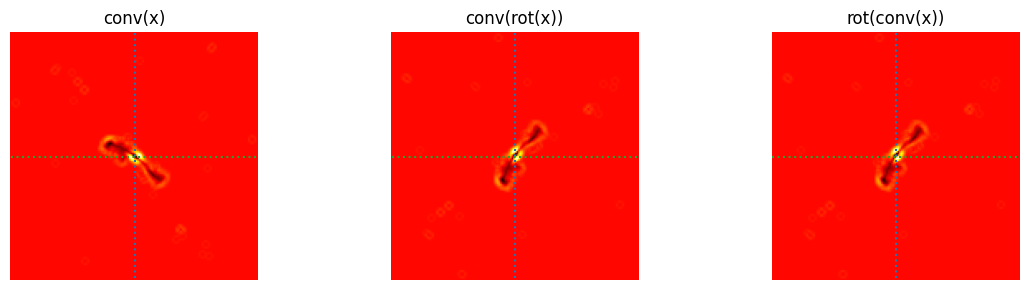

In [23]:
plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1); plt.imshow(x[0][0], cmap="hot"); plt.axis("off"); plt.title('original')
plt.plot([75,75], [0,149], ':', 'w'); plt.plot([0,149], [75,75], ':', 'w')
plt.subplot(1, 2, 2); plt.imshow(x_rotate[0][0], cmap="hot"); plt.axis("off"); plt.title(f"rotated : th={theta}")
plt.plot([75,75], [0,149], ':', 'w'); plt.plot([0,149], [75,75], ':', 'w')
plt.tight_layout(); plt.show()


plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1); plt.imshow(y[0][0], cmap="hot"); plt.title("conv(x)"); plt.axis("off")
plt.plot([75,75], [0,149], ':', 'w'); plt.plot([0,149], [75,75], ':', 'w')
plt.subplot(1, 3, 2); plt.imshow(y_rotate[0][0], cmap="hot"); plt.title("conv(rot(x))"); plt.axis("off")
plt.plot([75,75], [0,149], ':', 'w'); plt.plot([0,149], [75,75], ':', 'w')
plt.subplot(1, 3, 3); plt.imshow(y_expected[0][0], cmap="hot"); plt.title("rot(conv(x))"); plt.axis("off")
plt.plot([75,75], [0,149], ':', 'w'); plt.plot([0,149], [75,75], ':', 'w')
plt.tight_layout(); plt.show()

---

## Appendix: Minimal `requirements.txt`

Install torch/torchvision per PyTorch's official instructions. The rest can be installed via pip.

In [24]:
requirements = '''
numpy>=1.24
scipy>=1.10
matplotlib>=3.7
tqdm>=4.66
torch>=2.1,<2.4
torchvision>=0.16,<0.19
e2cnn==0.2.3
'''.strip()

print(requirements)

numpy>=1.24
scipy>=1.10
matplotlib>=3.7
tqdm>=4.66
torch>=2.1,<2.4
torchvision>=0.16,<0.19
e2cnn==0.2.3
